In [62]:
from langgraph.graph import START, END, StateGraph, MessagesState
from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage, RemoveMessage
from langchain_core.runnables import Runnable
from typing import Literal, Annotated
from collections.abc import Sequence

In [63]:
class State(MessagesState):
    summary:str

In [64]:
test_state = State()


In [65]:
test_state.get("summary", "")

''

get method gives us value of variable and if value is not defiened, it give our defined value then

In [66]:
def ask(state=State)-> State:
    print("*"*10)
    print("\n-------> Entering the ask state")
    for i in state['messages']:
        i.pretty_print()
    question = "What is your Question ?"
    print(question)

    return State(messages=[AIMessage(question), HumanMessage(input())])    

In [67]:
chat = ChatGroq(
    model="qwen/qwen3.6-27b",
    #max_output_tokens=100,
    temperature=0,
    seed=42
)

c:\Users\ANIK CHOWDHURY\Desktop\AI_Updated\.venv\Lib\site-packages\pydantic\main.py:263: UserWarning: WARNING! seed is not default parameter.
                    seed was transferred to model_kwargs.
                    Please confirm that seed is what you intended.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)


In [68]:
def chatbot(state:State)-> State:
    print("\n--------------> Entering Chatbot:")
    response = chat.invoke(state['messages'])
    response.pretty_print()
    system_message = f'''
    Here is the Quick Summary of what has been discussed so far:
    {state.get("summary","")}

    Keep this in mind as you answer the next question.
    '''
    response = chat.invoke([SystemMessage(system_message)]+state["messages"])
    response.pretty_print()
    return State(messages = [response])

In [69]:
def ask_another(state=State)->State:
    print("\n --------------> Entering Ask Another State:")
    for i in state['messages']:
        i.pretty_print()
    question = "Any other question ? (Yes/No)"
    print(question)

    return State(messages=[AIMessage(content=question), HumanMessage(content=input().strip())])

In [70]:
def summarise_and_delete_messages(state:State) -> State:
    print(f"----------> Entering summarise_and_delete_messages:")

    new_conversation = ""
    for i in state["messages"]:
        new_conversation += f"{i.type}: {i.content}\n\n"

    summary_instructions = f"""
update the ongoing summary by incorporating the new lines of conversation below.
Build upon the previous summary rather than repeating it so that the result reflects
the most recent context and developments.

Previous Summary:
{state.get("summary","")}

New Conversation:
{new_conversation}
"""

    print(summary_instructions)
    summary = chat.invoke([HumanMessage(summary_instructions)])

    remove_messages = [RemoveMessage(id=i.id) for i in state["messages"][:-5]]
    return State(messages=remove_messages, summary=summary.content)

In [71]:
def routing(state: State) -> Literal["summarise_and_delete_messages", "__end__"]:
    if state["messages"][-1].content.strip().lower() == "yes":
        return "summarise_and_delete_messages"
    else:
        return "__end__"

In [72]:
graph = StateGraph(State)

graph.add_node("ask", ask)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another", ask_another)
graph.add_node("summarise_and_delete_messages", summarise_and_delete_messages)

In [73]:
graph.add_edge(START, "ask")
graph.add_edge("ask", "chatbot")
graph.add_edge("chatbot", "ask_another")
graph.add_conditional_edges(source="ask_another", path=routing)
graph.add_edge("summarise_and_delete_messages", "ask")

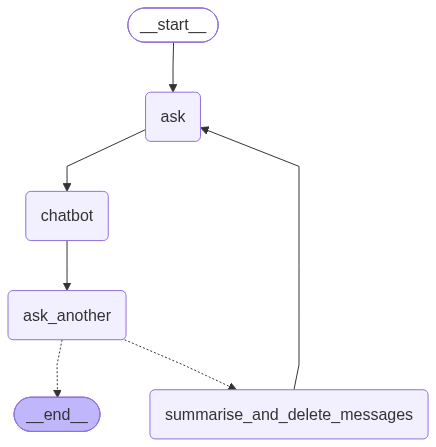

In [74]:
graph_complied = graph.compile()

graph_complied

In [ ]:
graph_complied.invoke(MessagesState(messages=[]))